In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
from torch import autograd as Grad

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib.tri as mtri
import matplotlib
from IPython.display import display, clear_output


import ipywidgets as widgets
from IPython.display import display
import trimesh

import random
import math

import time
import os
import json

import copy



import open3d as o3d
print(o3d.__path__)
print('Using open3d version',o3d.__version__)
# Suppress Open3D warnings
o3d.utility.set_verbosity_level(o3d.utility.VerbosityLevel.Error)


from visuals import *

from bns_utils import *
from mesh_processing import *

import differential
import importlib
importlib.reload(differential)
from differential import *

two_pi = 2*torch.pi
diffmod = DifferentialModule()

# Set the device that we will create the BPS on

device = 'mps'

total_num_samples = 10000 #total number of samples PER TRIANGLE, for the optimisation

print(f"Using device: {device}")

['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Using open3d version 0.18.0
Using device: mps


In [2]:
#Read in a config file that specifies the settings for a BPS (e.g. the sdf, the coarse mesh file, the blend function, the polynomial degree)
#e.g. sphere100, torus100, camera200, spike


with open("configs/surfaces/heightfield-test.json", "r") as f:
    config_dict = json.load(f)


    

In [3]:

import BPS
importlib.reload(BPS)
from BPS import BPS_fast


# instantiate
bps = BPS_fast( config_dict['surface-config'], device=device)


Using open3d version at ['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Using open3d version at ['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Initialising BPS on mps
HalfEdgeTriangleMesh with 12 points and 60 half edges.
mean edge length tensor(1.0515, device='mps:0')
Using Local Scales
Assiging a halfedge to each vertex.
Preparing V_he for halfedge mesh
Prepared V_he for halfedge mesh.

Optimising V_he.
Finished optimising V_he.

base triangle verts torch.float32
sharp edges obj []
sharp edges o3d []
sharp halfedges: []
Computing rotations.


In [4]:
def rotate_xy(x, y, angle_deg, center):
    theta = np.deg2rad(angle_deg)
    c, s = np.cos(theta), np.sin(theta)

    xr = x - center[0]
    yr = y - center[1]

    x_rot = c * xr - s * yr + center[0]
    y_rot = s * xr + c * yr + center[1]

    return x_rot, y_rot


In [5]:
%matplotlib widget

In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from mpl_toolkits.mplot3d import Axes3D


/Users/romywilliamson/Documents/BNS/bns/BPS.py:750: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  V_face = torch.tensor(self.V[verts, :], dtype=torch.float32, device=x.device)   # (3,3)
/Users/romywilliamson/Documents/BNS/bns/bns_utils.py:201: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  v_i = torch.tensor(V_face[i, :], dtype=torch.float32)
/Users/romywilliamson/Documents/BNS/bns/bns_utils.py:202: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  v_ip1 = torch.tensor(V_face[(i+1)%3, :], dtype=torch.float32)
/Users/romywilliamson/Documents/BN

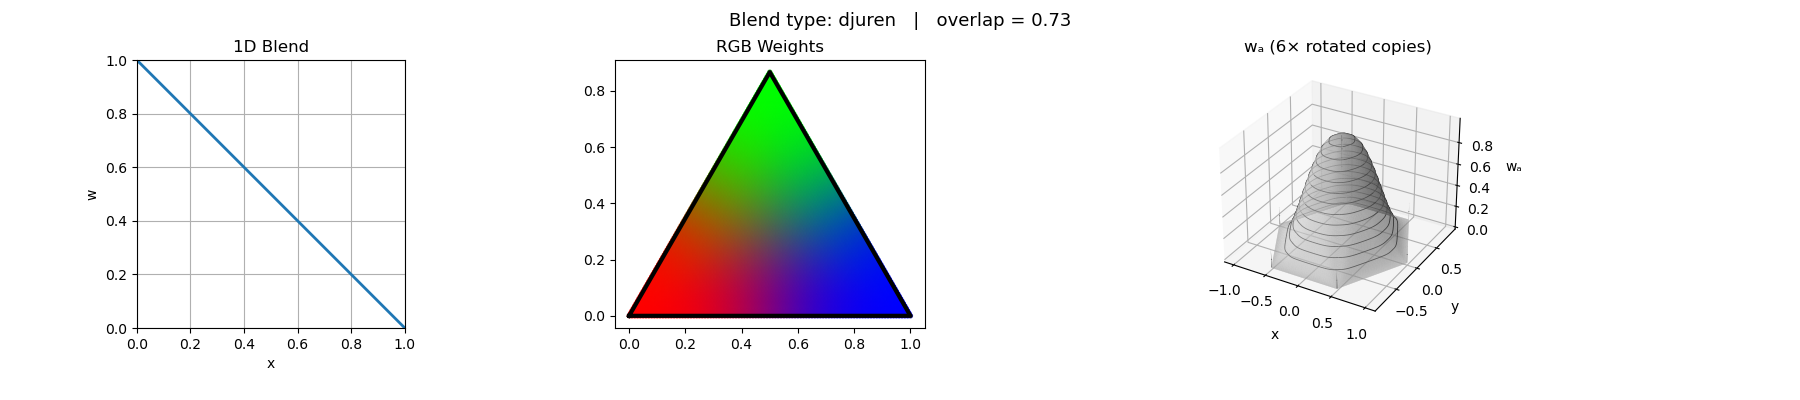

In [7]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.tri as mtri
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path
import numpy as np
import torch

# ======================================================
# Helpers
# ======================================================
def rotate_xy(x, y, angle_deg, center=(0.0, 0.0)):
    """Rotate (x,y) by angle (degrees) around center."""
    angle = np.deg2rad(angle_deg)
    cx, cy = center
    x0 = x - cx
    y0 = y - cy
    xr = np.cos(angle) * x0 - np.sin(angle) * y0 + cx
    yr = np.sin(angle) * x0 + np.cos(angle) * y0 + cy
    return xr, yr

# ======================================================
# Output directory
# ======================================================
outdir = Path("blend_plots_pdf")
outdir.mkdir(parents=True, exist_ok=True)

blend_types = ['bary', 'pou_inv_exp', 'pou_trig', 'pou_circular', 'pou_simple_exp', 'djuren']
blend_types = [ 'djuren']
#blend_types = [ 'bary']
overlap_params = [0.73]

# ======================================================
# Triangle vertices and grid
# ======================================================
A = np.array([0.0, 0.0])
B = np.array([0.5, np.sqrt(3)/2])
C = np.array([1.0, 0.0])

n = 100
x, y = [], []

for i in range(n + 1):
    for j in range(n + 1 - i):
        u = i / n
        v = j / n
        w = 1.0 - u - v
        p = u*A + v*B + w*C
        x.append(p[0])
        y.append(p[1])

x = np.array(x)
y = np.array(y)

# Radii for 2D blend
radii = torch.stack([
    torch.tensor(np.sqrt(x**2 + y**2)),
    torch.tensor(np.sqrt((x - 0.5)**2 + (y - np.sqrt(3)/2)**2)),
    torch.tensor(np.sqrt((x - 1.0)**2 + y**2))
])

# Input tensor for 2D blend
inp = torch.tensor(
    np.stack([x, y], axis=1),
    dtype=torch.float32
).unsqueeze(0)

# ======================================================
# Main loop
# ======================================================
for cur_overlap_param in overlap_params:
    for cur_blend_type in blend_types:

        # ================= BARYCENTRIC OPTION =================
        if cur_blend_type == 'bary':
            # 2D weights: linear barycentric functions
            # w_a is 1 at vertex A, 0 on opposite edge BC
            w_a = 1.0 - (x + (y / (np.sqrt(3)/2)) * 0.5)  # linear from A to BC
            # Rotate triangle so B and C become the "top" vertex to define w_b, w_c
            w_b = (2 / np.sqrt(3) ) * y  
            w_c = 1.0 - w_a - w_b
            
            # Clip to [0,1] just in case
            w_a = np.clip(w_a, 0, 1)
            w_b = np.clip(w_b, 0, 1)
            w_c = np.clip(w_c, 0, 1)
            
            # 1D weights along the edge from A to B
            x_1d = np.linspace(0, 1, 400)
            w_1d = 1.0 - x_1d  # simple linear from 1 → 0
            
        elif cur_blend_type == 'djuren':
            w_a = bps.blend_weight(
                inp, [None,None,None], i=0, j=0, face_index=0, blend_type='djuren', overlap_param=None
            )
            w_b = bps.blend_weight(
                inp, [None,None,None], i=2, j=0, face_index=0, blend_type='djuren', overlap_param=None
            )
            w_c = bps.blend_weight(
                inp, [None,None,None], i=1, j=0, face_index=0, blend_type='djuren', overlap_param=None
            )
            x_1d = np.linspace(0, 1, 400)
            w_1d = 1.0 - x_1d  # simple linear from 1 → 0

        # ================= STANDARD BLENDS =================
        else:
            # ---- Compute 2D weights ----
            w_a = bps.blend_weight(
                inp, radii[[0,1,2]],
                i=0, j=0,
                blend_type=cur_blend_type,
                overlap_param=cur_overlap_param
            ).detach().cpu().numpy().reshape(-1)
            print('did a')

            w_b = bps.blend_weight(
                inp, radii[[1,2,0]],
                i=1, j=0,
                blend_type=cur_blend_type,
                overlap_param=cur_overlap_param
            ).detach().cpu().numpy().reshape(-1)

            w_c = bps.blend_weight(
                inp, radii[[2,0,1]],
                i=2, j=0,
                blend_type=cur_blend_type,
                overlap_param=cur_overlap_param
            ).detach().cpu().numpy().reshape(-1)

            # ---- 1D slice along line from vertex 0 → vertex 1 ----
            x_1d = np.linspace(0, 1, 400)
            r0 = 1.0 - x_1d        # weight for first vertex
            r1 = x_1d              # weight for second vertex
            r2 =  torch.tensor(np.sqrt((x_1d - 1.0)**2 + (x_1d)**2)) # third vertex outside this line
            radii_1d = torch.tensor([r1, r0, r2], dtype=torch.float32)

            w_1d = bps.blend_weight(
                torch.tensor(x_1d, dtype=torch.float32),
                radii_1d,
                blend_type=cur_blend_type,
                overlap_param=cur_overlap_param
            ).detach().cpu().numpy()

        # ---- Triangulation for 2D plot ----
        triang = mtri.Triangulation(x, y)
        mask = mtri.TriAnalyzer(triang).get_flat_tri_mask(0.01)
        triang.set_mask(mask)

        # ======================================================
        # PLOTTING
        # ======================================================
        fig = plt.figure(figsize=(18, 4))
        fig.suptitle(
            f"Blend type: {cur_blend_type}   |   overlap = {cur_overlap_param}",
            fontsize=13,
            y=0.97
        )

        gs = GridSpec(
            1, 4,
            figure=fig,
            width_ratios=[1.0, 1.0, 1.35, 0.05],
            left=0.04,
            right=0.96,
            bottom=0.18,
            top=0.85,
            wspace=0.30
        )

        # ---- Plot 1: 1D blend ----
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.plot(x_1d, w_1d, lw=2)
        ax1.set_title("1D Blend")
        ax1.set_xlabel("x")
        ax1.set_ylabel("w")
        ax1.grid(True)
        # Make x and y scales equal and restrict axes to [0,1]
        ax1.set_xlim(0, 1)
        ax1.set_ylim(0, 1)
        ax1.set_aspect('equal', adjustable='box')

        # ---- Plot 2: RGB weights ----
        ax2 = fig.add_subplot(gs[0, 1])
        rgb = np.clip(np.stack([w_a, w_b, w_c], axis=1), 0, 1)
        ax2.scatter(x, y, c=rgb, s=8)
        ax2.plot(*zip(A,B,C,A), 'k', lw=3)
        ax2.set_aspect('equal')
        ax2.set_title("RGB Weights")

        # ---- Plot 3: 3D surface with rotated copies ----
        ax3 = fig.add_subplot(gs[0, 2], projection='3d')
        center = (0.0, 0.0)
        angles = [0, 60, 120, 180, 240, 300]

        for angle in angles:
            x_rot, y_rot = rotate_xy(x, y, angle, center)
            triang_rot = mtri.Triangulation(x_rot, y_rot)
            mask = mtri.TriAnalyzer(triang_rot).get_flat_tri_mask(0.01)
            triang_rot.set_mask(mask)

            ax3.plot_trisurf(
                triang_rot,
                w_a,
                color='lightgray',
                edgecolor='none',
                alpha=0.9
            )

            ax3.tricontour(
                triang_rot,
                w_a,
                levels=15,
                colors='k',
                linewidths=0.6
            )

        ax3.set_title("wₐ (6× rotated copies)")
        ax3.set_xlabel("x")
        ax3.set_ylabel("y")
        ax3.set_zlabel("wₐ")
        ax3.tick_params(pad=2)

        # ---- Save PDF ----
        pdf_path = outdir / f"blend_{cur_blend_type}_overlap_{cur_overlap_param:.2f}.pdf"
        fig.savefig(pdf_path, format="pdf")

        plt.show()
        plt.close(fig)
